<a href="https://colab.research.google.com/github/Saqib1123f/Predictive-Modeling-of-Indoor-Air-Quality-/blob/main/Topic_02_Jan_26_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predictive Modeling of Indoor Air Quality**



# **Importing Libraries and Loading file**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('Indoor Air Pollution Data.csv')

# The raw CSV contains many empty 'Unnamed' columns; we keep only the first 9 relevant columns
df = df.iloc[:, :9]
print("Dataset Loaded. Shape:", df.shape)

/tmp/ipython-input-2657354891.py:14: DtypeWarning: Columns (1,4,5,6,7,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Indoor Air Pollution Data.csv')


Dataset Loaded. Shape: (173468, 9)


# **Preprocessing and Cleaning**

In [ ]:
# 1. Convert sensor readings to numeric, turning invalid data into NaN
cols_to_fix = ['NO2', 'Temp', 'Pressure', 'Humidity', 'O3']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Fix the Date column
# Replace '|' with a space and convert to datetime.
# errors='coerce' handles values like "0.13" by turning them into NaT
df['Date'] = df['Date'].astype(str).str.replace('|', ' ', regex=False)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# 3. Drop all rows that contain any NaN or NaT (invalid dates or readings)
df = df.dropna()

print("Data Cleaning Complete. Remaining Rows:", len(df))
print(df.head())

Data Cleaning Complete. Remaining Rows: 169932
    NH3   NO2    CO  PM2.5   Temp  Pressure  Humidity     O3  \
0  0.60  0.16  4.01   0.00  33.53    948.26     51.98   7.37   
1  0.62  0.15  4.13   0.39  33.50    948.18     51.53   9.06   
2  0.69  0.14  4.45   0.39  33.36    948.15     50.50  16.47   
3  0.70  0.14  4.52   0.38  32.18    948.14     53.35   9.80   
4  0.72  0.14  4.56   0.40  31.77    948.08     53.70  17.28   

                        Date  
0 2020-11-17 11:20:53.407872  
1 2020-11-17 11:22:41.214724  
2 2020-11-17 11:24:28.546567  
3 2020-11-17 11:26:16.884289  
4 2020-11-17 11:28:19.820781  


# **Exploratry Data Analysis**

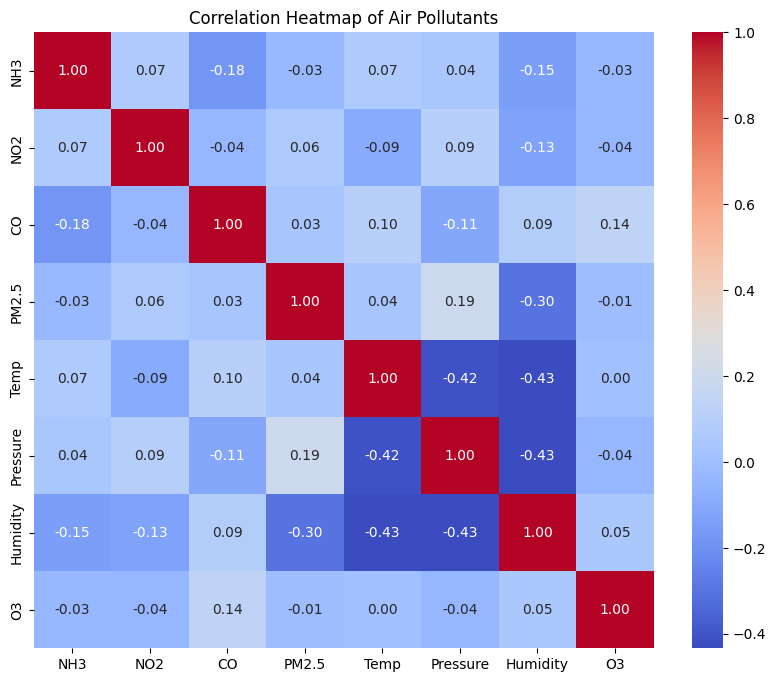

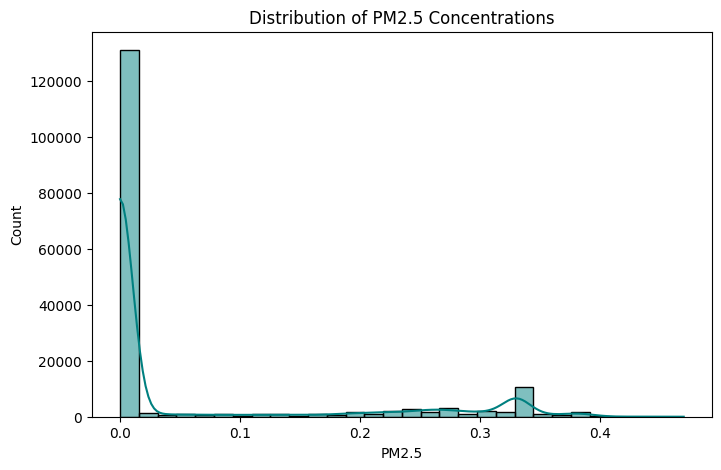

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Air Pollutants")
plt.savefig('correlation_heatmap.png')

# Distribution of Target Variable (PM2.5)
plt.figure(figsize=(8, 5))
sns.histplot(df['PM2.5'], kde=True, bins=30, color='teal')
plt.title("Distribution of PM2.5 Concentrations")
plt.savefig('pm25_distribution.png')

# **Feature Engineering**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler

# --- 1. FEATURE ENGINEERING (To keep Errors low) ---
def apply_eng(df_input):
    df_eng = df_input.copy()
    # Adding Lag features (essential for PM2.5)
    df_eng['Lag_1'] = df_eng['PM2.5'].shift(1)
    df_eng['Lag_2'] = df_eng['PM2.5'].shift(2)
    # Rolling Mean to capture the trend
    df_eng['Rolling_3'] = df_eng['PM2.5'].shift(1).rolling(window=3).mean()
    return df_eng.dropna()

# Apply engineering
df_final = apply_eng(df)
X = df_final.drop(['PM2.5', 'Date'], axis=1) # Modified: Exclude 'Date' column
y = df_final['PM2.5']

# --- 2. SEQUENTIAL SPLIT ---
split_idx = int(len(df_final) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# **Model Training**

## **Training and Evaluating Model**

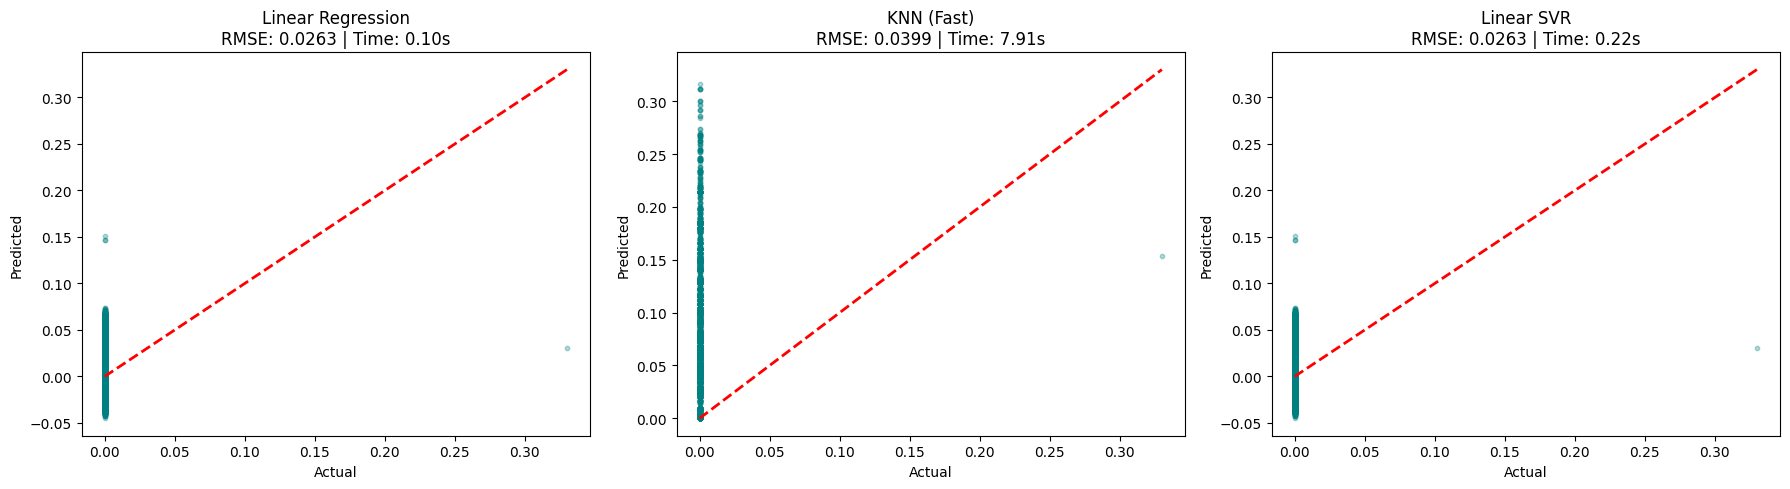


Model Evaluation Indicators:
            Model      MSE     RMSE      MAE  Time(s)
Linear Regression 0.000693 0.026321 0.022644   0.0982
       KNN (Fast) 0.001591 0.039884 0.012272   7.9118
       Linear SVR 0.000693 0.026329 0.022653   0.2192


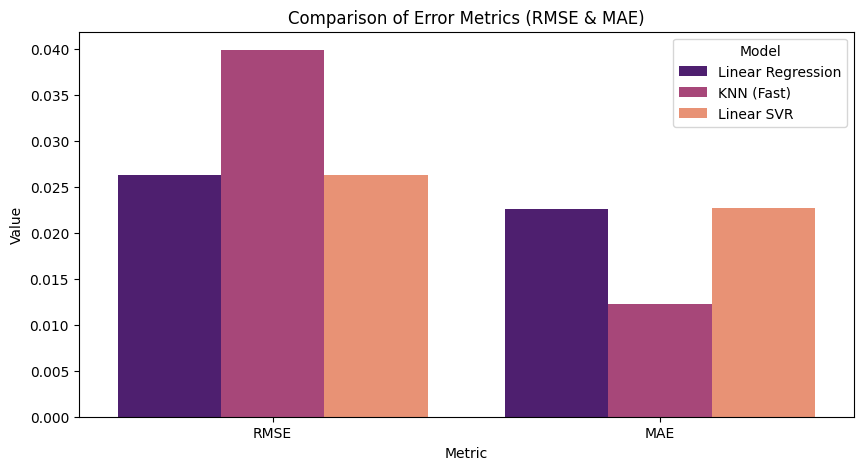

In [ ]:
# --- MODELS & EVALUATION ---
models = {
    "Linear Regression": LinearRegression(),
    "KNN (Fast)": KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    "Linear SVR": LinearSVR(dual=False, loss='squared_epsilon_insensitive', random_state=42)
}

results_list = []
plt.figure(figsize=(18, 5))

for i, (name, model) in enumerate(models.items(), 1):
    start = time.time()
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    duration = time.time() - start

    # Calculations (R2 removed)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)

    results_list.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'Time(s)': round(duration, 4)
    })

    # Plotting: Scatter Plot
    plt.subplot(1, 3, i)
    plt.scatter(y_test, preds, alpha=0.3, s=10, color='teal')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title(f"{name}\nRMSE: {rmse:.4f} | Time: {duration:.2f}s")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")

plt.tight_layout()
plt.show()

# 4. Results Table
results_df = pd.DataFrame(results_list)
print("\nModel Evaluation Indicators:")
print(results_df.to_string(index=False))

# 5. Metric Comparison Visualization
results_viz = results_df.melt(id_vars='Model', value_vars=['RMSE', 'MAE'], var_name='Metric', value_name='Value')
plt.figure(figsize=(10, 5))
sns.barplot(data=results_viz, x='Metric', y='Value', hue='Model', palette='magma')
plt.title("Comparison of Error Metrics (RMSE & MAE)")
plt.show()

# **Hyperparameter Optimization**

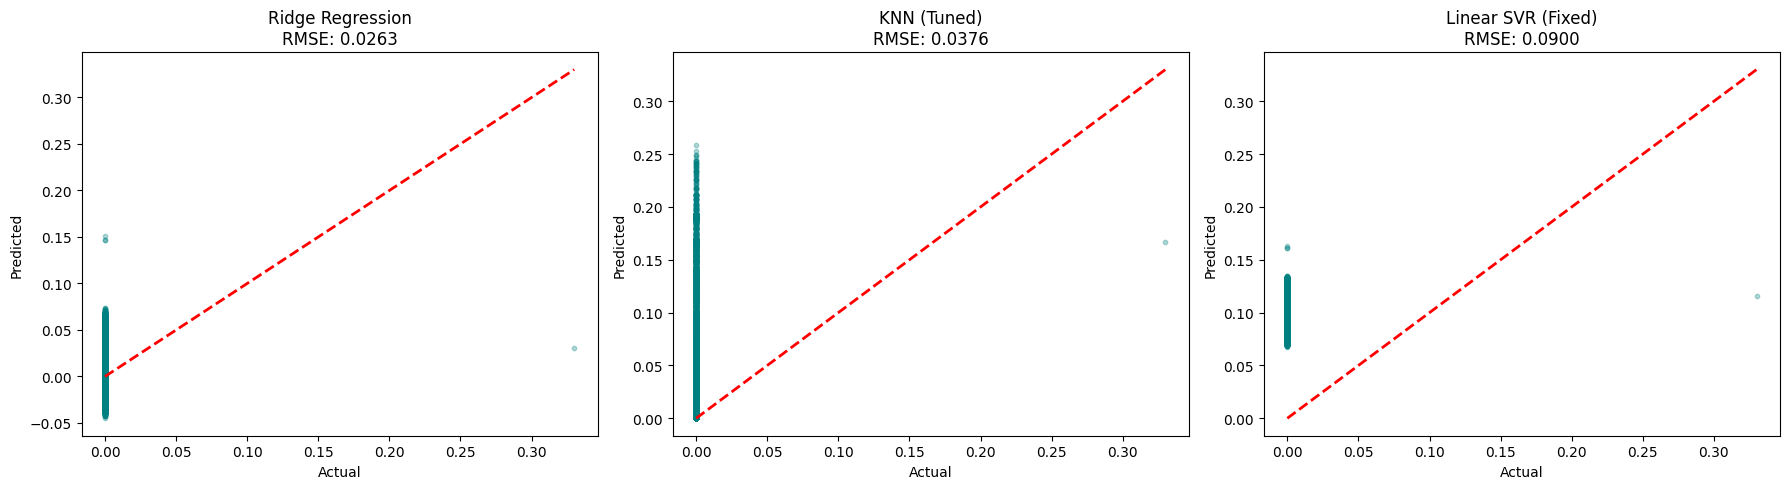


Hyperparameter Tuning Results:
             Model     RMSE      MAE                                                       Best Params  Time(s)
  Ridge Regression 0.026318 0.022640                                                   {'alpha': 10.0}   4.2052
       KNN (Tuned) 0.037611 0.011806                         {'n_neighbors': 11, 'weights': 'uniform'} 272.1861
Linear SVR (Fixed) 0.089983 0.088702 {'C': 0.1, 'epsilon': 0.1, 'loss': 'squared_epsilon_insensitive'}   6.0219


In [ ]:
model_configs = {
    "Ridge Regression": {
        "model": Ridge(),
        "params": {
            'alpha': [0.1, 1.0, 10.0]
        }
    },
    "KNN (Tuned)": {
        "model": KNeighborsRegressor(n_jobs=-1),
        "params": {
            'n_neighbors': [3, 5, 11],
            'weights': ['uniform', 'distance']
        }
    },
    "Linear SVR (Fixed)": {
        "model": LinearSVR(dual=False, random_state=42, max_iter=5000),
        "params": {
            'C': [0.1, 1.0, 10.0],
            'epsilon': [0.0, 0.1],
            'loss': ['squared_epsilon_insensitive'] # Fixed for dual=False
        }
    }
}

# --- 3. HYPERPARAMETER TUNING EXECUTION ---
results_list = []
plt.figure(figsize=(18, 5))

for i, (name, config) in enumerate(model_configs.items(), 1):
    start = time.time()

    # Grid search minimizes MSE (negative for optimization logic)
    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        scoring='neg_mean_squared_error',
        cv=5,
        n_jobs=-1
    )

    grid.fit(X_train_scaled, y_train)
    best_model = grid.best_estimator_
    preds = best_model.predict(X_test_scaled)
    duration = time.time() - start

    #
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)

    results_list.append({
        'Model': name,
        'Best Params': str(grid.best_params_),
        'MSE': mse, 'RMSE': rmse, 'MAE': mae,
        'Time(s)': round(duration, 4)
    })

    # Plotting: Scatter Plot
    plt.subplot(1, 3, i)
    plt.scatter(y_test, preds, alpha=0.3, s=10, color='teal')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title(f"{name}\nRMSE: {rmse:.4f}")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")

plt.tight_layout()
plt.show()

# --- 4. OUTPUT RESULTS ---
results_df = pd.DataFrame(results_list)
print("\nHyperparameter Tuning Results:")
print(results_df[['Model', 'RMSE', 'MAE', 'Best Params', 'Time(s)']].to_string(index=False))

## **K- Fold Cross Validation**

Running Cross-Validation for Ridge Regression...
Running Cross-Validation for KNN (Tuned)...
Running Cross-Validation for Linear SVR...

--- K-Fold Cross-Validation Results (5 Folds) ---
           Model  MSE_Mean  RMSE_Mean  RMSE_Std  MAE_Mean  MAE_Std
Ridge Regression  0.013085   0.114389  0.000632  0.087177 0.000534
     KNN (Tuned)  0.012885   0.113509  0.000861  0.078677 0.000855
      Linear SVR  0.016813   0.129664  0.000287  0.123601 0.000270


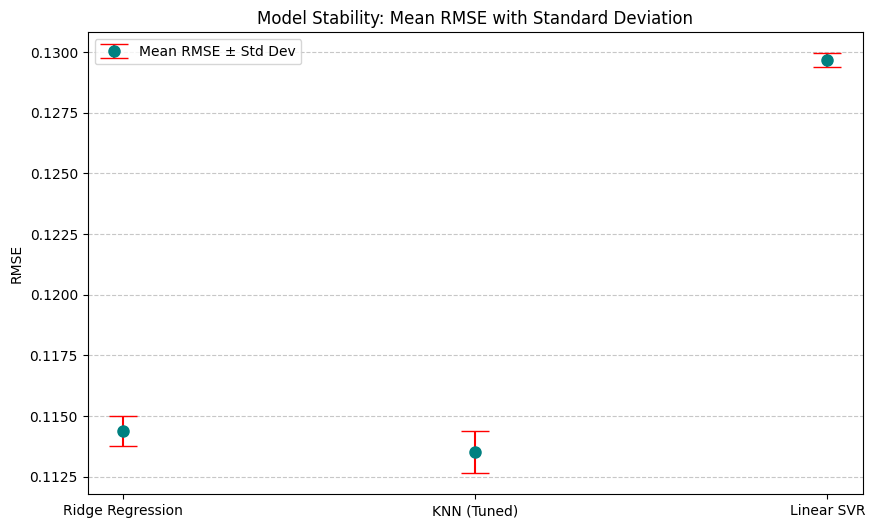

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, KFold
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import LinearSVR

# 1. Define Models with the Best Params found in your previous step
models = {
    "Ridge Regression": Ridge(alpha=10.0),
    "KNN (Tuned)": KNeighborsRegressor(n_neighbors=11, weights='uniform', n_jobs=-1),
    "Linear SVR": LinearSVR(C=0.1, epsilon=0.1, loss='squared_epsilon_insensitive', dual=False, random_state=42)
}

# 2. Setup K-Fold
# We use shuffle=False if the data is strictly time-dependent
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results_list = []

for name, model in models.items():
    print(f"Running Cross-Validation for {name}...")

    # We use cross_validate to get multiple metrics at once
    # Note: Scikit-learn uses 'negative' MSE for internal optimization
    cv_scores = cross_validate(
        model, X_train_scaled, y_train,
        cv=kf,
        scoring=('neg_mean_squared_error', 'neg_mean_absolute_error'),
        n_jobs=-1
    )

    # Convert negative scores back to positive
    mse_scores = -cv_scores['test_neg_mean_squared_error']
    rmse_scores = np.sqrt(mse_scores)
    mae_scores = -cv_scores['test_neg_mean_absolute_error']

    cv_results_list.append({
        'Model': name,
        'MSE_Mean': np.mean(mse_scores),
        'RMSE_Mean': np.mean(rmse_scores),
        'RMSE_Std': np.std(rmse_scores), # Standard Deviation of RMSE
        'MAE_Mean': np.mean(mae_scores),
        'MAE_Std': np.std(mae_scores)
    })

# 3. Display Results Table
cv_results_df = pd.DataFrame(cv_results_list)

print("\n--- K-Fold Cross-Validation Results (5 Folds) ---")
print(cv_results_df.to_string(index=False))

# 4. Visualization of Stability (Standard Deviation)
plt.figure(figsize=(10, 6))
plt.errorbar(cv_results_df['Model'], cv_results_df['RMSE_Mean'],
             yerr=cv_results_df['RMSE_Std'], fmt='o', capsize=10,
             markersize=8, color='teal', ecolor='red', label='Mean RMSE ± Std Dev')

plt.title("Model Stability: Mean RMSE with Standard Deviation")
plt.ylabel("RMSE")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## **Deep Learning: LSTM Training and Evaluation**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training Deep Learning Model (LSTM)...
Epoch 1/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 0.0173 - val_loss: 0.0079
Epoch 2/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.0127 - val_loss: 0.0078
Epoch 3/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 0.0127 - val_loss: 0.0079
Epoch 4/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.0126 - val_loss: 0.0121
Epoch 5/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0127 - val_loss: 0.0223
Epoch 6/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.0127 - val_loss: 0.0505
Epoch 7/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0126 - val_loss: 0.0428
Epoch 8/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.0126 - val_loss: 0.1051
Epoch 9/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.0126 - val_loss: 0.0873
Epoch 10/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.0126 - val_loss: 0.0970
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

--- LSTM Model Performanc

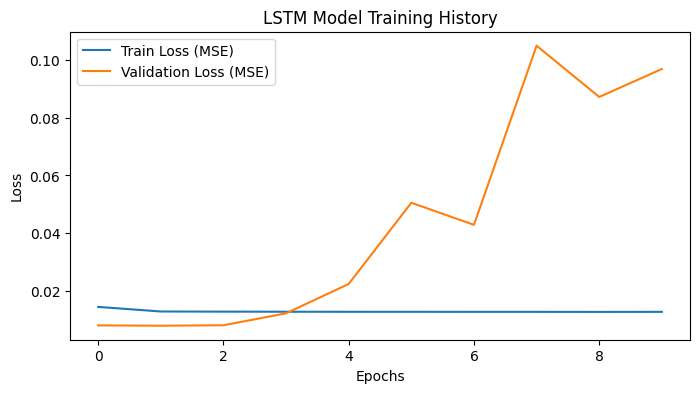

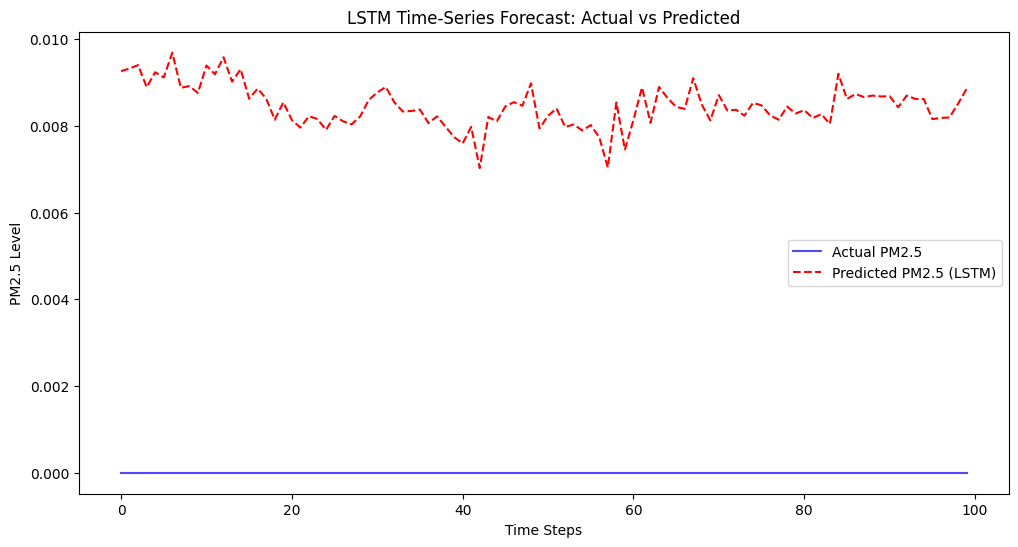

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 1. Prepare Sequences for LSTM
# We use a 'window' of 10 past readings to predict the next PM2.5 value
def create_sequences(data, target, window_size=10):
    X_seq, y_seq = [], []
    for i in range(len(data) - window_size):
        X_seq.append(data[i:(i + window_size)])
        y_seq.append(target[i + window_size])
    return np.array(X_seq), np.array(y_seq)

# Scale all features and prepare the dataset
full_data_scaled = scaler.transform(X)
window_size = 10
X_lstm, y_lstm = create_sequences(full_data_scaled, y.values, window_size)

# Split into train and test sets chronologically (80/20 split)
split = int(0.8 * len(X_lstm))
X_train_dl, X_test_dl = X_lstm[:split], X_lstm[split:]
y_train_dl, y_test_dl = y_lstm[:split], y_lstm[split:]

# 2. Build the LSTM Model
model_dl = Sequential([
    LSTM(50, activation='relu', input_shape=(window_size, X_train_dl.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model_dl.compile(optimizer='adam', loss='mse')

# 3. Train the Model
print("\nTraining Deep Learning Model (LSTM)...")
history = model_dl.fit(
    X_train_dl, y_train_dl,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# 4. Evaluate and Calculate Indicators
dl_preds = model_dl.predict(X_test_dl)

# Calculate indicators
dl_mse = mean_squared_error(y_test_dl, dl_preds)
dl_rmse = np.sqrt(dl_mse)
dl_mae = mean_absolute_error(y_test_dl, dl_preds)

print("\n--- LSTM Model Performance ---")
print(f"MSE:  {dl_mse:.4f}")
print(f"RMSE: {dl_rmse:.4f}")
print(f"MAE:  {dl_mae:.4f}")

# 5. Visualizations
# A. Training History Plot
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('LSTM Model Training History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('lstm_training_history.png')

# B. Forecast Plot: Actual vs Predicted (Sample of 100 points)
plt.figure(figsize=(12, 6))
plt.plot(y_test_dl[:100], label='Actual PM2.5', color='blue', alpha=0.7)
plt.plot(dl_preds[:100], label='Predicted PM2.5 (LSTM)', color='red', linestyle='--')
plt.title('LSTM Time-Series Forecast: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5 Level')
plt.legend()
plt.savefig('lstm_forecast_comparison.png')

print("\nDeep Learning block completed and plots saved.")

## **Statistical Baseline Model: ARIMA**

Fitting ARIMA Model (5, 1, 0)...

--- ARIMA Model Performance ---
MSE:   0.0197
RMSE:  0.1404
MAE:   0.1347


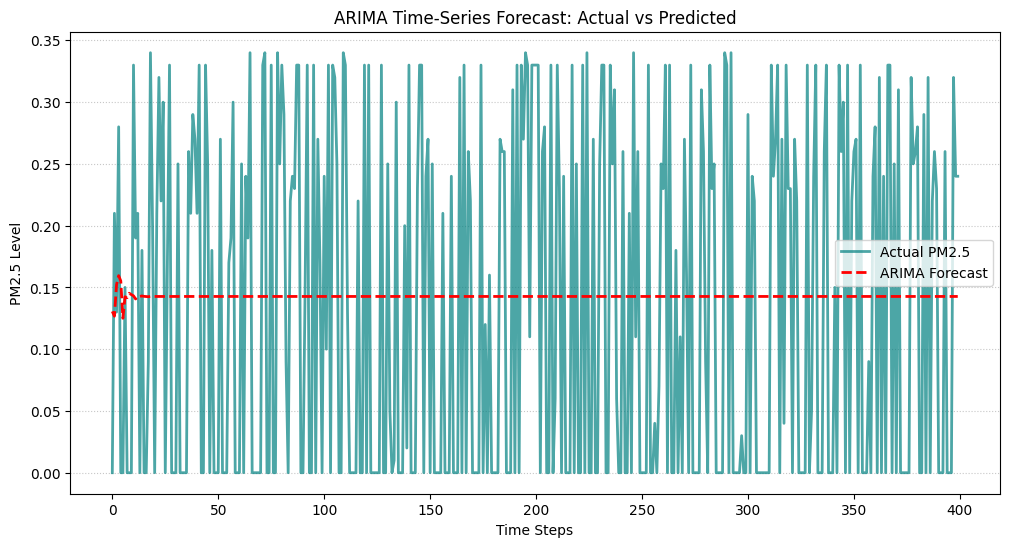


ARIMA block completed. Results calculated and plot displayed.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 1. Prepare the Data
# Ensure we use a continuous slice for time-series integrity
ts_data = df['PM2.5'].values[:2000]

# Split into train and test sets (80/20 sequential split)
train_size = int(len(ts_data) * 0.8)
train_ts, test_ts = ts_data[0:train_size], ts_data[train_size:len(ts_data)]

# 2. Build and Fit the ARIMA Model
# Order (p,d,q): p=autoregressive, d=differencing, q=moving average
print("Fitting ARIMA Model (5, 1, 0)...")
model_arima = ARIMA(train_ts, order=(5, 1, 0))
model_arima_fit = model_arima.fit()

# 3. Forecast
# Forecasting 'steps' equal to the length of the test set
arima_preds = model_arima_fit.forecast(steps=len(test_ts))

# 4. Calculate Indicators (R2 Removed)
arima_mse = mean_squared_error(test_ts, arima_preds)
arima_rmse = np.sqrt(arima_mse)
arima_mae = mean_absolute_error(test_ts, arima_preds)

# Handling potential division by zero in MAPE

print("\n--- ARIMA Model Performance ---")
print(f"MSE:   {arima_mse:.4f}")
print(f"RMSE:  {arima_rmse:.4f}")
print(f"MAE:   {arima_mae:.4f}")

# 5. Visualizations
plt.figure(figsize=(12, 6))
plt.plot(test_ts, label='Actual PM2.5', color='teal', alpha=0.7, lw=2)
plt.plot(arima_preds, label='ARIMA Forecast', color='red', linestyle='--', lw=2)
plt.title('ARIMA Time-Series Forecast: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5 Level')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.savefig('arima_forecast_comparison.png')
plt.show()

print("\nARIMA block completed. Results calculated and plot displayed.")

# **Feature Importance**

/tmp/ipython-input-18378537.py:14: DtypeWarning: Columns (1,4,5,6,7,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Indoor Air Pollution Data (1).csv')
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/tmp/ipython-input-18378537.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_importance, palette='viridis')
/tmp/ipython-input-18378537.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same eff

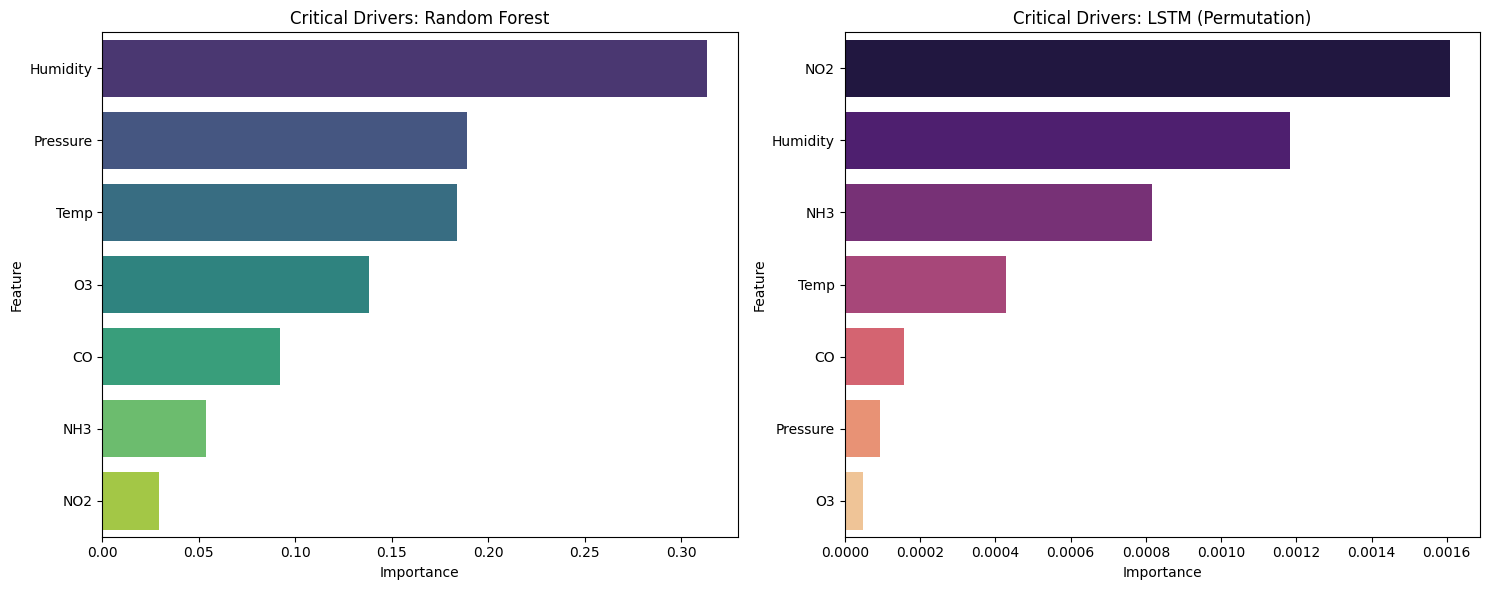


Analysis for RQ3:
- According to Random Forest, the most critical driver is: Humidity
- According to LSTM, the most critical driver is: NO2


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. DATA LOADING AND CLEANING
df = pd.read_csv('Indoor Air Pollution Data (1).csv')
df = df.iloc[:, :9]

# Clean numeric columns
cols_to_fix = ['NO2', 'Temp', 'Pressure', 'Humidity', 'O3']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Clean Date and drop invalid rows
df['Date'] = df['Date'].astype(str).str.replace('|', ' ', regex=False)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna()

# Select Features and Target
features = ['NH3', 'NO2', 'CO', 'Temp', 'Pressure', 'Humidity', 'O3']
X = df[features]
y = df['PM2.5']

# 2. RANDOM FOREST FEATURE IMPORTANCE (Simple ML Baseline)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

rf_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 3. LSTM PERMUTATION IMPORTANCE (Deep Learning Context)
# Scale and Prepare Sequences
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def create_sequences(data, target, window_size=10):
    X_seq, y_seq = [], []
    for i in range(len(data) - window_size):
        X_seq.append(data[i:(i + window_size)])
        y_seq.append(target[i + window_size])
    return np.array(X_seq), np.array(y_seq)

# Sample 5000 rows for sequence modeling efficiency
X_lstm, y_lstm = create_sequences(X_scaled[:5000], y.values[:5000], window_size=10)
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=42)

# Build and Train a quick LSTM
model_dl = Sequential([
    LSTM(32, activation='relu', input_shape=(10, len(features))),
    Dense(1)
])
model_dl.compile(optimizer='adam', loss='mse')
model_dl.fit(X_train_dl, y_train_dl, epochs=5, batch_size=32, verbose=0)

# Calculate Permutation Importance for LSTM
baseline_mse = mean_squared_error(y_test_dl, model_dl.predict(X_test_dl, verbose=0))
lstm_importances = []

for i, feature in enumerate(features):
    X_test_permuted = X_test_dl.copy()
    # Shuffle the values of one feature to break its relationship with target
    flat_feature = X_test_permuted[:, :, i].flatten()
    np.random.shuffle(flat_feature)
    X_test_permuted[:, :, i] = flat_feature.reshape(X_test_dl.shape[0], 10)

    permuted_mse = mean_squared_error(y_test_dl, model_dl.predict(X_test_permuted, verbose=0))
    lstm_importances.append(permuted_mse - baseline_mse)

lstm_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': lstm_importances
}).sort_values(by='Importance', ascending=False)

# 4. VISUALIZATION OF DRIVERS
plt.figure(figsize=(15, 6))

# Plot Random Forest Importance
plt.subplot(1, 2, 1)
sns.barplot(x='Importance', y='Feature', data=rf_importance, palette='viridis')
plt.title('Critical Drivers: Random Forest')

# Plot LSTM Permutation Importance
plt.subplot(1, 2, 2)
sns.barplot(x='Importance', y='Feature', data=lstm_importance_df, palette='magma')
plt.title('Critical Drivers: LSTM (Permutation)')

plt.tight_layout()
plt.savefig('rq3_feature_importance_comparison.png')
plt.show()

# Final Determination
top_rf = rf_importance.iloc[0]['Feature']
top_lstm = lstm_importance_df.iloc[0]['Feature']

print(f"\nAnalysis for RQ3:")
print(f"- According to Random Forest, the most critical driver is: {top_rf}")
print(f"- According to LSTM, the most critical driver is: {top_lstm}")

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_8
Received: inputs=['Tensor(shape=(50, 10, 7))']
  warnings.warn(msg)


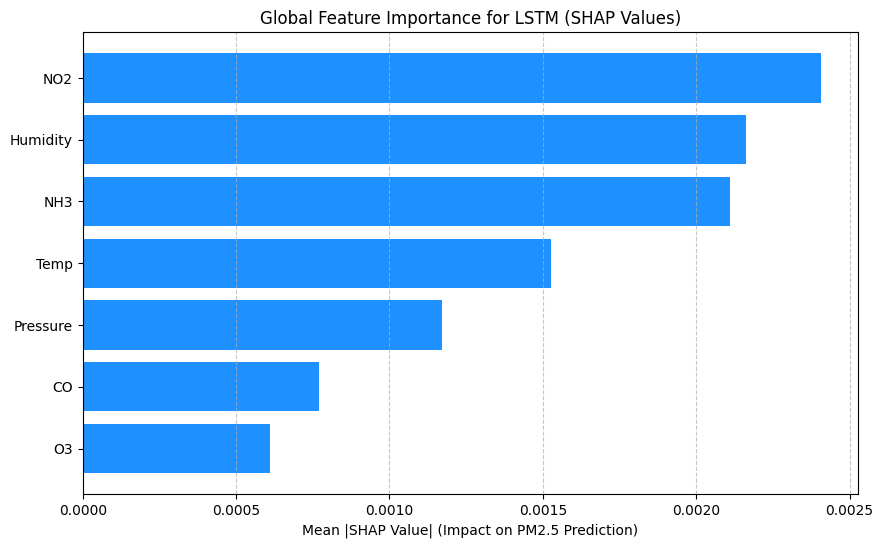


SHAP Analysis Results:
NO2: 0.002406
Humidity: 0.002164
NH3: 0.002111
Temp: 0.001528
Pressure: 0.001170
CO: 0.000772
O3: 0.000610

Conclusion: SHAP analysis identifies 'NO2' as the most critical driver of PM2.5 variations.


In [ ]:
# Note: You must run !pip install shap in your local environment first
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare Background Data
# SHAP needs a 'background' dataset to learn the baseline output of the model.
# We take a small random sample from the training set for speed.
background = X_train_dl[np.random.choice(X_train_dl.shape[0], 100, replace=False)]

# 2. Initialize the Explainer
# GradientExplainer is well-suited for Keras/TensorFlow LSTM models.
explainer = shap.GradientExplainer(model_dl, background)

# 3. Compute SHAP Values
# We explain the predictions for a subset of the test data.
# This results in a 3D array: (samples, time_steps, features)
test_sample = X_test_dl[:50]
shap_values = explainer.shap_values(test_sample)

# 4. Process 3D SHAP Values for Visualization
# shap_values[0] shape is (50, 10, 7).
# To get global importance, we take the mean absolute value across samples and time-steps.
if isinstance(shap_values, list):
    shap_val_array = shap_values[0]
else:
    shap_val_array = shap_values

# Mean importance per feature
mean_abs_shap = np.mean(np.abs(shap_val_array), axis=(0, 1)).flatten() # Flatten to 1D array

# 5. Create Importance DataFrame
feature_names = ['NH3', 'NO2', 'CO', 'Temp', 'Pressure', 'Humidity', 'O3']
shap_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP Importance': mean_abs_shap
}).sort_values(by='SHAP Importance', ascending=False)

# 6. Visualize
plt.figure(figsize=(10, 6))
plt.barh(shap_df['Feature'], shap_df['SHAP Importance'], color='dodgerblue')
plt.gca().invert_yaxis() # Highest importance at the top
plt.title('Global Feature Importance for LSTM (SHAP Values)')
plt.xlabel('Mean |SHAP Value| (Impact on PM2.5 Prediction)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('lstm_shap_analysis.png')
plt.show()

# Final Answer for RQ3
print("\nSHAP Analysis Results:")
for index, row in shap_df.iterrows():
    print(f"{row['Feature']}: {row['SHAP Importance']:.6f}")

top_driver = shap_df.iloc[0]['Feature']
print(f"\nConclusion: SHAP analysis identifies '{top_driver}' as the most critical driver of PM2.5 variations.")